# Jollibee Site Selection Using Machine Learning & Geospatial Analysis

This project identifies optimal locations for new Jollibee stores using spatial data, demographic features, and predictive modeling.

## 📦 Import Libraries

This section loads all required libraries for geospatial analysis, data manipulation, and visualization.  
We use:
- `geopandas` for spatial data
- `pandas` for tabular data
- `matplotlib` for visualization

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import glob

# Load Metro Manila boundary from adm3.shp
adm3 = gpd.read_file("data/phl_admbnda_adm3_psa_namria_20200529.shp")

## 📍 Filter Metro Manila (NCR)

We isolate the National Capital Region (NCR), which serves as the study area for Jollibee site selection.

In [2]:
print(adm3["ADM1_EN"].unique())

['Region IV-B' 'Region III' 'Region II' 'Region VIII' 'Region I'
 'Region IV-A' 'Cordillera Administrative Region' 'Region VI'
 'Bangsamoro Autonomous Region in Muslim Mindanao' 'Region XII'
 'Region VII' 'Region XIII' 'Region IX' 'Region X' 'Region V' 'Region XI'
 'National Capital Region']


In [23]:
metro_manila = adm3[adm3['ADM1_EN'] == "National Capital Region"]


# Read each CSV file into a separate variable
jollibee = pd.read_csv("poi/jollibee.csv")
mcdonalds = pd.read_csv("poi/mcdo.csv")
gas_stations = pd.read_csv("poi/gas.csv")
malls = pd.read_csv("poi/malls.csv")
heis = pd.read_csv("poi/hei.csv")
population_density = pd.read_csv("poi/pop.csv")
transpo = pd.read_csv("poi/transpo.csv")
hotel = pd.read_csv("poi/hotel.csv")

def convert_to_gdf(df):
    if {'Longitude', 'Latitude'}.issubset(df.columns):
        df["geometry"] = df.apply(lambda row: Point(row["Longitude"], row["Latitude"]), axis=1)
        gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

        # Ensure Metro Manila boundary is valid before filtering
        if not metro_manila.geometry.is_empty.all():
            gdf = gdf.clip(metro_manila)  # Use clip instead of within
        return gdf
    return None

# Convert all DataFrames to GeoDataFrames
jollibee_gdf = convert_to_gdf(jollibee)
mcdonalds_gdf = convert_to_gdf(mcdonalds)

jollibee_gdf.to_csv('jollibee_filtered.csv', index=False)
mcdonalds_gdf.to_csv('mcdo_filtered.csv', index=False)

gas_stations_gdf = convert_to_gdf(gas_stations)
malls_gdf = convert_to_gdf(malls)
heis_gdf = convert_to_gdf(heis)
#population_density_gdf = convert_to_gdf(population_density)
transpo_gdf = convert_to_gdf(transpo)
hotel_gdf = convert_to_gdf(hotel)

## 🗺️ Visualize Study Area

This map shows the geographic boundaries of Metro Manila to confirm the selected region.

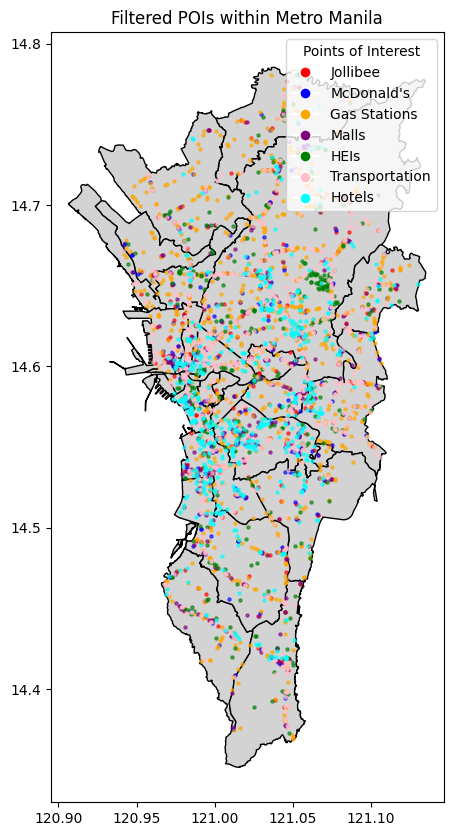

In [24]:
# Plot Metro Manila
fig, ax = plt.subplots(figsize=(10, 10))
metro_manila.plot(ax=ax, color="lightgray", edgecolor="black")

# Define POI datasets and their corresponding colors
poi_data = {
    "Jollibee": (jollibee_gdf, "red"),
    "McDonald's": (mcdonalds_gdf, "blue"),
    "Gas Stations": (gas_stations_gdf, "orange"),
    "Malls": (malls_gdf, "purple"),
    "HEIs": (heis_gdf, "green"),
    #"Population Density": (population_density_gdf, "brown"),
    "Transportation": (transpo_gdf, "pink"),
    "Hotels": (hotel_gdf, "cyan"),
}

# Plot each POI dataset
for label, (gdf, color) in poi_data.items():
    if gdf is not None:
        gdf.plot(ax=ax, color=color, markersize=5, alpha=0.6, label=label)

# Manually create a legend using proxy artists
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label) 
                  for label, (_, color) in poi_data.items()]

# Add legend to the plot
ax.legend(handles=legend_handles, loc="upper right", title="Points of Interest")

plt.title("Filtered POIs within Metro Manila")
plt.show()


## ⚙️ Additional Tools for Spatial Analysis

We import specialized libraries for:
- Distance calculations
- Spatial indexing
- Efficient nearest-neighbor searches

In [25]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import Point

# Load POI datasets
jollibee = pd.read_csv("poi/jollibee.csv")
mcdonalds = pd.read_csv("poi/mcdo.csv")
gas_stations = pd.read_csv("poi/gas.csv")
malls = pd.read_csv("poi/malls.csv")
heis = pd.read_csv("poi/hei.csv")
transpo = pd.read_csv("poi/transpo.csv")
hotel = pd.read_csv("poi/hotel.csv")
pop = pd.read_csv("poi/pop.csv")  # High-resolution population density data

# Convert to GeoDataFrame
def to_gdf(df):
    return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")

gdf_jollibee = to_gdf(jollibee)
gdf_mcdo = to_gdf(mcdonalds)
gdf_gas = to_gdf(gas_stations)
gdf_malls = to_gdf(malls)
gdf_heis = to_gdf(heis)
gdf_transpo = to_gdf(transpo)
gdf_hotel = to_gdf(hotel)
gdf_pop = to_gdf(pop)

## 📏 Compute Nearest Distances

This function calculates the distance from each candidate location to the nearest point of interest (e.g., malls, competitors, etc.).

In [26]:
def nearest_distance(source_gdf, target_gdf):
    source_coords = np.array(list(source_gdf.geometry.apply(lambda geom: (geom.x, geom.y))))
    target_coords = np.array(list(target_gdf.geometry.apply(lambda geom: (geom.x, geom.y))))

    tree = cKDTree(target_coords)
    
    # Query 2 nearest neighbors
    distances, indices = tree.query(source_coords, k=2)
    
    # If the nearest (index 0) is itself with distance 0, take the second one
    nearest_nonself = []
    for dist_list, idx_list in zip(distances, indices):
        if dist_list[0] == 0:  # self-match
            nearest_nonself.append(dist_list[1])
        else:
            nearest_nonself.append(dist_list[0])
    
    return np.array(nearest_nonself)


# Compute nearest distances
gdf_jollibee["nearest_mcdo"] = nearest_distance(gdf_jollibee, gdf_mcdo)
gdf_jollibee["nearest_mall"] = nearest_distance(gdf_jollibee, gdf_malls)
gdf_jollibee["nearest_gas"] = nearest_distance(gdf_jollibee, gdf_gas)
gdf_jollibee["nearest_hei"] = nearest_distance(gdf_jollibee, gdf_heis)
gdf_jollibee["nearest_transpo"] = nearest_distance(gdf_jollibee, gdf_transpo)
gdf_jollibee["nearest_hotel"] = nearest_distance(gdf_jollibee, gdf_hotel)

## 📊 Count Nearby Establishments

We compute how many points (e.g., competitors or attractors) fall within a given radius of each candidate location.

In [27]:
from sklearn.neighbors import BallTree

def count_within_radius(source_gdf, target_gdf, radius):
    source_coords = np.radians(np.array(list(source_gdf.geometry.apply(lambda geom: (geom.y, geom.x)))))
    target_coords = np.radians(np.array(list(target_gdf.geometry.apply(lambda geom: (geom.y, geom.x)))))

    tree = BallTree(target_coords, metric="haversine")
    counts = tree.query_radius(source_coords, r=radius/6371000, count_only=True)  # Earth's radius in meters
    return counts

# Compute density counts
gdf_jollibee["mcdo_within_1km"] = count_within_radius(gdf_jollibee, gdf_mcdo, 1000)
gdf_jollibee["malls_within_1km"] = count_within_radius(gdf_jollibee, gdf_malls, 1000)
gdf_jollibee["gas_within_1km"] = count_within_radius(gdf_jollibee, gdf_gas, 1000)
gdf_jollibee["heis_within_1km"] = count_within_radius(gdf_jollibee, gdf_heis, 1000)

gdf_jollibee["mcdo_within_0.5km"] = count_within_radius(gdf_jollibee, gdf_mcdo, 500)
gdf_jollibee["malls_within_0.5km"] = count_within_radius(gdf_jollibee, gdf_malls, 500)
gdf_jollibee["gas_within_0.5km"] = count_within_radius(gdf_jollibee, gdf_gas, 500)
gdf_jollibee["heis_within_0.5km"] = count_within_radius(gdf_jollibee, gdf_heis, 500)

gdf_jollibee["mcdo_within_0.1km"] = count_within_radius(gdf_jollibee, gdf_mcdo, 100)
gdf_jollibee["malls_within_0.1km"] = count_within_radius(gdf_jollibee, gdf_malls, 100)
gdf_jollibee["gas_within_0.1km"] = count_within_radius(gdf_jollibee, gdf_gas, 100)
gdf_jollibee["heis_within_0.1km"] = count_within_radius(gdf_jollibee, gdf_heis, 100)

## 👥 Assign Population Influence

This function assigns population data to each candidate site based on proximity to populated areas.

In [28]:
import numpy as np
from scipy.spatial import cKDTree

def assign_nearest_population(poi_df, pop_df, pop_col, lat_col="latitude", lon_col="longitude", add_distance=True):
    # Extract coordinates
    poi_coords = np.array(list(zip(poi_df[lon_col], poi_df[lat_col])))
    pop_coords = np.array(list(zip(pop_df[lon_col], pop_df[lat_col])))

    # Build KDTree
    pop_tree = cKDTree(pop_coords)

    # Query nearest neighbor
    distances, idx = pop_tree.query(poi_coords, k=1)

    # Assign population values
    poi_df = poi_df.copy()
    poi_df["pop"] = pop_df.iloc[idx][pop_col].values

    # Optionally add distances
    if add_distance:
        poi_df["dist_to_pop"] = distances

    return poi_df

gdf_jollibee = assign_nearest_population(
    gdf_jollibee,
    gdf_pop,
    pop_col="phl_general_2020",
    lat_col="Latitude",
    lon_col="Longitude",
    add_distance=False
)

In [29]:
gdf_jollibee.head(50)
gdf_jollibee.to_csv('jollibee_gdf.csv', index=False)

## 🏢 Combine Points of Interest

We merge datasets (e.g., gas stations, malls, highways) into a single GeoDataFrame for unified analysis.

In [30]:
gdf_combined = gpd.GeoDataFrame(
    pd.concat([gdf_gas, gdf_heis, gdf_malls], ignore_index=True),
    crs="EPSG:43857"
)

# Compute nearest distances
gdf_combined["nearest_mcdo"] = nearest_distance(gdf_combined, gdf_mcdo)
gdf_combined["nearest_mall"] = nearest_distance(gdf_combined, gdf_malls)
gdf_combined["nearest_gas"] = nearest_distance(gdf_combined, gdf_gas)
gdf_combined["nearest_hei"] = nearest_distance(gdf_combined, gdf_heis)
gdf_combined["nearest_transpo"] = nearest_distance(gdf_combined, gdf_transpo)
gdf_combined["nearest_hotel"] = nearest_distance(gdf_combined, gdf_hotel)

gdf_combined["mcdo_within_1km"] = count_within_radius(gdf_combined, gdf_mcdo, 1000)
gdf_combined["malls_within_1km"] = count_within_radius(gdf_combined, gdf_malls, 1000)
gdf_combined["gas_within_1km"] = count_within_radius(gdf_combined, gdf_gas, 1000)
gdf_combined["heis_within_1km"] = count_within_radius(gdf_combined, gdf_heis, 1000)

gdf_combined["mcdo_within_0.5km"] = count_within_radius(gdf_combined, gdf_mcdo, 500)
gdf_combined["malls_within_0.5km"] = count_within_radius(gdf_combined, gdf_malls, 500)
gdf_combined["gas_within_0.5km"] = count_within_radius(gdf_combined, gdf_gas, 500)
gdf_combined["heis_within_0.5km"] = count_within_radius(gdf_combined, gdf_heis, 500)

gdf_combined["mcdo_within_0.1km"] = count_within_radius(gdf_combined, gdf_mcdo, 100)
gdf_combined["malls_within_0.1km"] = count_within_radius(gdf_combined, gdf_malls, 100)
gdf_combined["gas_within_0.1km"] = count_within_radius(gdf_combined, gdf_gas, 100)
gdf_combined["heis_within_0.1km"] = count_within_radius(gdf_combined, gdf_heis, 100)

gdf_combined = assign_nearest_population(
    gdf_combined,
    gdf_pop,
    pop_col="phl_general_2020",
    lat_col="Latitude",
    lon_col="Longitude",
    add_distance=False
)


In [31]:
gdf_combined.head(50)

,Name,Fulladdress,Street,Municipality,Categories,Phone,Phones,Claimed,Review_Count,Average_Rating,...,heis_within_1km,mcdo_within_0.5km,malls_within_0.5km,gas_within_0.5km,heis_within_0.5km,mcdo_within_0.1km,malls_within_0.1km,gas_within_0.1km,heis_within_0.1km,pop
0,Petron Fuel Station,"P2QG+PR9, Deparo Rd, Caloocan, Metro Manila",P2QG+PR9,Deparo Rd,Alternative fuel station,O1HAZ6uvPPXc2roPmNvF6AU,NaN,NO,18.0,3.8,...,1,1,0,4,1,1,0,1,0,51.261695
1,Cleanfuel Congressional,"9 Congressional Ave Ext, Quezon City, 1107 Met...",9 Congressional Ave Ext,Quezon City,Gas company,_FDAZ-2QOY3l2roP89_zuAU,NaN,NO,38.0,4.6,...,1,0,0,3,0,0,0,1,0,20.195636
2,Petron MIAA,"MIA Road, NAIA Complex, Brgy. 197, Pasay City,...","MIA Road, NAIA Complex, Brgy. 197",Pasay City,Gas company,0929 101 4937,"0929 101 4937, +63 929 101 4937",NO,4.0,2.8,...,0,0,0,1,0,0,0,1,0,9.422950
3,Petron Xavierville Gas station,"10A, 1108 Xavier Ville St, Quezon City, Metro ...",10A,1108 Xavier Ville St,Gas company,6VDAZ-6gH53k2roP0P_GyQI,NaN,NO,15.0,4.6,...,4,0,0,3,0,0,0,1,0,11.907598
4,Phoenix Gasoline Station - Multinational,"FXXX+F37, Multinational Ave, Parañaque, Metro ...",FXXX+F37,Multinational Ave,Gas company,vE_AZ5KrBr2l2roPoKeg4Q8,NaN,NO,28.0,4.5,...,2,1,0,2,1,0,0,1,0,14.748702
5,Unioil Mindanao Talipapa,"25 1116 Mindanao Ave Ext, Novaliches, Quezon C...",25 1116 Mindanao Ave Ext,"Novaliches, Quezon City",Gas company,0933 307 5006,"0933 307 5006, +63 933 307 5006",YES,19.0,4.6,...,0,0,0,5,0,0,0,2,0,22.228911
6,X-finity Gas Station,"P356+PX2, Commonwealth Ave, Novaliches, Quezon...",P356+PX2,Commonwealth Ave,Gas company,I1HAZ6CMJKC-0-kPjIrY0QU,NaN,NO,15.0,4.2,...,3,1,0,8,0,0,0,2,0,23.992837
7,Xfinity gas Commonwealth,"lot 9 blk, 73 Commonwealth Ave, Novaliches, Qu...",lot 9 blk,73 Commonwealth Ave,"Gas company,Gas station",UU7AZ9qBAu6fvr0PyLSuuAk,NaN,YES,32.0,4.5,...,3,0,0,5,2,0,0,1,0,6.943241
8,Abi Gasoline Station,"Q3C4+J9Q, Langit Rd, Caloocan, Metro Manila",Q3C4+J9Q,Langit Road,Gas station,603AZ9uyKK731e8PlLiV0AY,NaN,NO,7.0,3.4,...,1,0,1,1,0,0,0,1,0,260.265089
9,ALTA,"corner Dahlia Ave, Novaliches, Quezon City, Me...",corner Dahlia Ave,"Novaliches, Quezon City",Gas station,I1HAZ6CMJKC-0-kPjIrY0QU,NaN,NO,2.0,4.5,...,2,0,0,4,0,0,0,1,0,31.483013


## 🤖 Prepare Data for Modeling

We prepare features and labels, including splitting data into training and testing sets.

ROC AUC: 0.805
Average Precision: 0.408
Accuracy: 0.837
Precision: 0.667
Recall: 0.436
F1 Score: 0.527


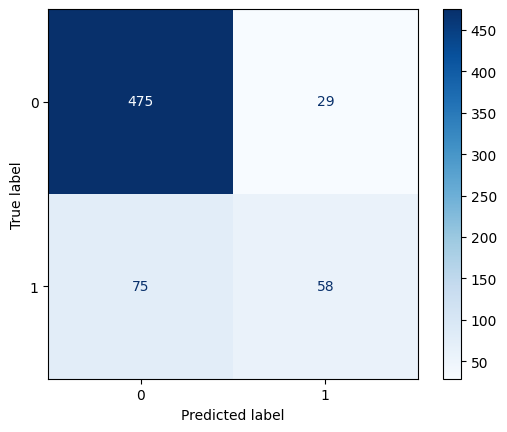

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Load your Jollibee and random negative samples
# Positive samples: Jollibee locations
jollibee_df = gdf_jollibee
jollibee_df["label"] = 1

# Negative samples: random points without Jollibee
random_df = gdf_combined
random_df["label"] = 0

# Combine into one dataset
df = pd.concat([jollibee_df, random_df], ignore_index=True).fillna(0)

# Select features
features = [
    'nearest_mall', 'nearest_gas', 'nearest_hei',
    #'nearest_transpo', 'nearest_hotel',
    'malls_within_1km', 'gas_within_1km', 'heis_within_1km',
    'malls_within_0.5km', 'gas_within_0.5km', 'heis_within_0.5km',
]

X = df[features]
y = df["label"]

# Train/Test Split
# stratify=y ensures class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=75, stratify=y
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# Evaluate
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print all metrics
print(f"ROC AUC: {roc_auc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")

## 🏆 Rank Candidate Locations

We score all potential locations based on model predictions to identify optimal sites for new Jollibee stores.

In [33]:
# Rank candidates
# Score ALL candidate locations (including withheld ones)
df["score"] = model.predict_proba(df[features])[:, 1]
df_ranked = df.sort_values(by="score", ascending=False)

print(df_ranked[['Name','score']])
# Save ranked list for inspection
#df_ranked.to_csv("ranked_candidates.csv", index=False)

                                                   Name     score
390            Jollibee XRC Square - Montaña, Montalban  0.973158
367                        Jollibee -Vermosa Drive Thru  0.964580
354                                            Jollibee  0.960654
402                Jollibee - Petron Marilao Northbound  0.947908
209                                     Jollibee Obando  0.942508
...                                                 ...       ...
1496  Department of Chemical Engineering, University...  0.001443
1491  UP Diliman Institute of Civil Engineering (UP-...  0.001443
1415                 College of Business Administration  0.001427
1488  University of the Philippines Department of Ps...  0.001427
1493  UP Diliman Electrical and Electronics Engineer...  0.000632

[2122 rows x 2 columns]


## 🔁 Model Refinement

We refine or retrain the model to improve prediction accuracy.


===== RandomForest =====
ROC AUC: 0.990
Average Precision: 0.842
Accuracy: 0.951
Precision: 0.935
Recall: 0.865
F1 Score: 0.898

===== GradientBoosting =====
ROC AUC: 0.990
Average Precision: 0.912
Accuracy: 0.974
Precision: 0.954
Recall: 0.940
F1 Score: 0.947

===== LogisticRegression =====
ROC AUC: 0.883
Average Precision: 0.539
Accuracy: 0.828
Precision: 0.624
Recall: 0.774
F1 Score: 0.691

===== XGBoost =====
ROC AUC: 0.992
Average Precision: 0.898
Accuracy: 0.970
Precision: 0.940
Recall: 0.940
F1 Score: 0.940


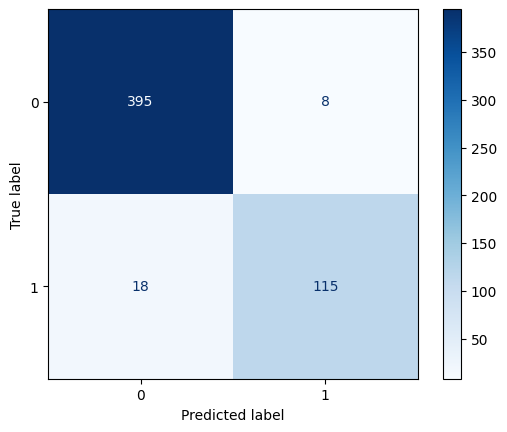

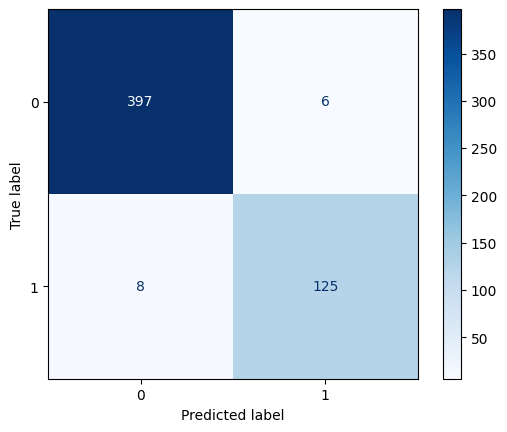

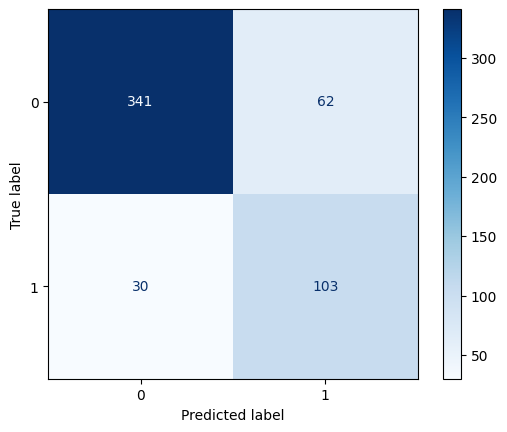

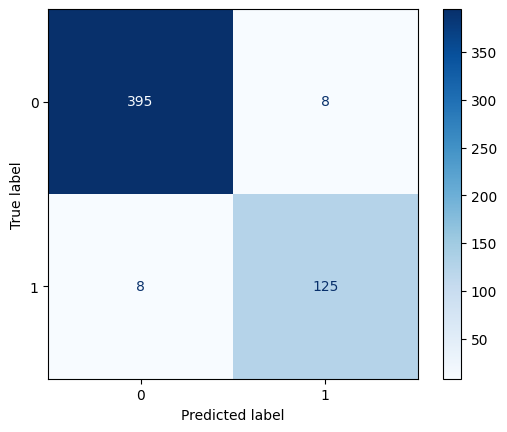

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# ===== 1. Prepare Data =====
jollibee_df = gdf_jollibee.copy()
jollibee_df["label"] = 1

random_df = gdf_combined.copy()
random_df["label"] = 0

candidate_df = random_df.sample(frac=0.2, random_state=42)  # 20% as candidates
random_df = random_df.drop(candidate_df.index)

df = pd.concat([jollibee_df, random_df], ignore_index=True).fillna(0)

features = [
    'nearest_mall', 'nearest_gas', 'nearest_hei',
    #'nearest_transpo', 'nearest_hotel',
    #'malls_within_1km', 'gas_within_1km', 'heis_within_1km',
    'malls_within_0.5km', 'gas_within_0.5km', 'heis_within_0.5km',#'mcdo_within_0.5km',
    'malls_within_0.1km', 'gas_within_0.1km', 'heis_within_0.1km'#,'mcdo_within_0.1km'
    #'nearest_mcdo',# 'pop'
]

X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=75, stratify=y
)

# ===== 2. Models to Compare =====
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',
        random_state=42)
}

# ===== 3. Train, Evaluate and Print =====
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    avg_precision = average_precision_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"ROC AUC: {roc_auc:.3f}")
    print(f"Average Precision: {avg_precision:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues", values_format="d")


## 🔍 Model Explainability (SHAP)

We use SHAP values to interpret which features most influence site selection decisions.

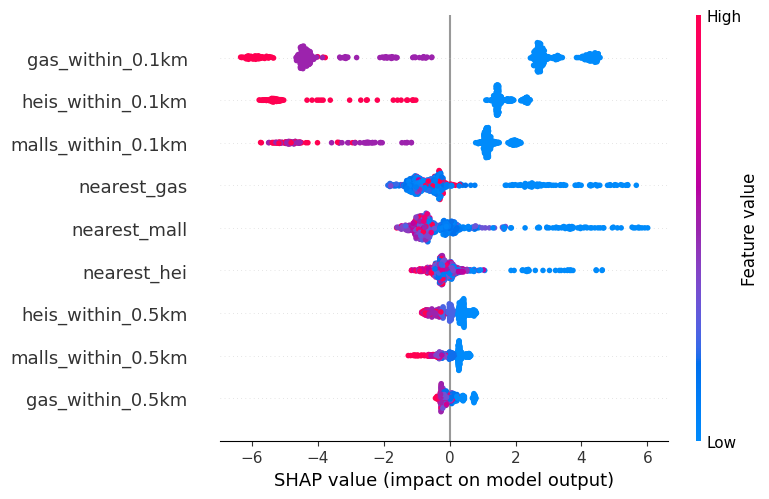

              Feature  Positive-Red  Positive-Blue  Negative-Red  \
0        nearest_mall            15            139           253   
1         nearest_gas            13             91           255   
2         nearest_hei            78             97           190   
3  malls_within_0.5km            72            271           193   
4    gas_within_0.5km            28            192           199   
5   heis_within_0.5km            75            268           193   
6  malls_within_0.1km             0            414           122   
7    gas_within_0.1km             0            275           261   
8   heis_within_0.1km             0            429           107   

   Negative-Blue  
0            129  
1            177  
2            171  
3              0  
4            117  
5              0  
6              0  
7              0  
8              0  


In [41]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===== 4. Feature Influence using SHAP =====
best_model = models["XGBoost"]
best_model.fit(X_train, y_train)

# Create a SHAP explainer
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# --- Global feature importance summary (bar) ---
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig("shap_summary_bar_jollibee.png", dpi=300)
plt.close()

# --- Detailed beeswarm summary ---
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm_jollibee.png", dpi=300)
plt.show()

# ===== Count positive/negative SHAP combined with red/blue feature values =====
feature_names = X_test.columns
results = []

for i, feature in enumerate(feature_names):
    shap_vals = shap_values.values[:, i]   # SHAP values for this feature
    feature_vals = shap_values.data[:, i]  # Original feature values
    
    # Median split for red (high) vs blue (low)
    threshold = np.median(feature_vals)
    high_mask = feature_vals > threshold
    low_mask = feature_vals <= threshold
    
    pos_mask = shap_vals > 0
    neg_mask = shap_vals < 0
    
    positive_red = np.sum(pos_mask & high_mask)
    positive_blue = np.sum(pos_mask & low_mask)
    negative_red = np.sum(neg_mask & high_mask)
    negative_blue = np.sum(neg_mask & low_mask)
    
    results.append({
        "Feature": feature,
        "Positive-Red": int(positive_red),
        "Positive-Blue": int(positive_blue),
        "Negative-Red": int(negative_red),
        "Negative-Blue": int(negative_blue)
    })

# Put results into a dataframe for easy viewing
results_df = pd.DataFrame(results)
print(results_df)

## 🧪 Model Experiments

We test multiple models and configurations to ensure robust performance and reliable predictions.

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    accuracy_score, f1_score
)
import shap
import matplotlib.pyplot as plt

# ===== 1. Prepare Data =====
jollibee_df = gdf_jollibee.copy()
jollibee_df["label"] = 1

random_df = gdf_combined.copy()
random_df["label"] = 0

candidate_df = random_df.sample(frac=0.2, random_state=42)  # 20% as candidates
random_df = random_df.drop(candidate_df.index)

df = pd.concat([jollibee_df, random_df], ignore_index=True).fillna(0)

features = [
    'nearest_mall', 'nearest_gas', 'nearest_hei',
    'malls_within_0.5km', 'gas_within_0.5km', 'heis_within_0.5km',
    'malls_within_0.1km', 'gas_within_0.1km', 'heis_within_0.1km',
]

X = df[features]
y = df["label"]

# ===== 2. Define Models =====
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42)
}

# ===== 3. Cross-validation setup =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===== 4. Train, Cross-Validate, Evaluate, SHAP =====
for name, model in models.items():
    print(f"\n===== {name} =====")

    metrics = {
        "ROC_AUC": [],
        "Avg_Precision": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": []
    }

    shap_values_all = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # Store metrics
        metrics["ROC_AUC"].append(roc_auc_score(y_test, y_pred_prob))
        metrics["Avg_Precision"].append(average_precision_score(y_test, y_pred_prob))
        metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
        metrics["Precision"].append(precision_score(y_test, y_pred))
        metrics["Recall"].append(recall_score(y_test, y_pred))
        metrics["F1"].append(f1_score(y_test, y_pred))

        # Compute SHAP values for tree-based models
        if name in ["RandomForest", "GradientBoosting", "XGBoost"]:
            explainer = shap.Explainer(model, X_train)
            shap_values = explainer(X_test)
            shap_values_all.append(shap_values)

    # Print averaged metrics
    print("Mean Metrics (5-fold CV):")
    for key, vals in metrics.items():
        print(f"{key}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")
    

#     # Plot SHAP summary for tree-based models
#     if name in ["RandomForest", "GradientBoosting", "XGBoost"]:
#         # Combine SHAP values across folds
#         shap_values_combined = np.concatenate([sv.values for sv in shap_values_all], axis=0)
#         shap_values_obj = shap.Explanation(values=shap_values_combined, base_values=np.zeros(shap_values_combined.shape[0]), data=X.values)
#         shap.summary_plot(shap_values_obj, X, plot_type="bar", max_display=15)



===== RandomForest =====
Mean Metrics (5-fold CV):
ROC_AUC: 0.986 ± 0.007
Avg_Precision: 0.968 ± 0.011
Accuracy: 0.950 ± 0.009
Precision: 0.947 ± 0.014
Recall: 0.847 ± 0.033
F1: 0.894 ± 0.020

===== GradientBoosting =====
Mean Metrics (5-fold CV):
ROC_AUC: 0.988 ± 0.008
Avg_Precision: 0.979 ± 0.012
Accuracy: 0.966 ± 0.006
Precision: 0.962 ± 0.016
Recall: 0.899 ± 0.035
F1: 0.929 ± 0.015

===== LogisticRegression =====
Mean Metrics (5-fold CV):
ROC_AUC: 0.859 ± 0.022
Avg_Precision: 0.806 ± 0.028
Accuracy: 0.817 ± 0.012
Precision: 0.612 ± 0.029
Recall: 0.741 ± 0.040
F1: 0.669 ± 0.009

===== XGBoost =====
Mean Metrics (5-fold CV):
ROC_AUC: 0.990 ± 0.007
Avg_Precision: 0.980 ± 0.012
Accuracy: 0.966 ± 0.007
Precision: 0.952 ± 0.024
Recall: 0.910 ± 0.036
F1: 0.930 ± 0.015


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    accuracy_score, f1_score
)

# ===== 1. Prepare Data =====
jollibee_df = gdf_jollibee.copy()
jollibee_df["label"] = 1

random_df = gdf_combined.copy()
random_df["label"] = 0

candidate_df = random_df.sample(frac=0.2, random_state=42)  # 20% as candidates
random_df = random_df.drop(candidate_df.index)

df = pd.concat([jollibee_df, random_df], ignore_index=True).fillna(0)

features = [
    'nearest_mall', 'nearest_gas', 'nearest_hei',
    #'nearest_transpo', 'nearest_hotel',
    #'malls_within_1km', 'gas_within_1km', 'heis_within_1km',
    'malls_within_0.5km', 'gas_within_0.5km', 'heis_within_0.5km',
    'malls_within_0.1km', 'gas_within_0.1km', 'heis_within_0.1km',
    #'nearest_mcdo',# 'pop'
]
X = df[features]
y = df["label"]

# ===== 2. Models to Compare =====
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, random_state=42
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42
    )
}

# ===== 3. Repeat 100 times and collect metrics =====
n_runs = 100
results = {name: [] for name in models}

for run in range(n_runs):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=run
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        metrics = {
            "ROC AUC": roc_auc_score(y_test, y_pred_prob),
            "Average Precision": average_precision_score(y_test, y_pred),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        }
        results[name].append(metrics)

# ===== 4. Calculate and print mean ± std for each model =====
for name, metrics_list in results.items():
    print(f"\n===== {name} (averaged over {n_runs} runs) =====")
    metrics_df = pd.DataFrame(metrics_list)
    for metric in metrics_df.columns:
        mean_val = metrics_df[metric].mean()
        std_val = metrics_df[metric].std()
        print(f"{metric}: {mean_val:.3f} ± {std_val:.3f}")



===== RandomForest (averaged over 100 runs) =====
ROC AUC: 0.984 ± 0.006
Average Precision: 0.832 ± 0.031
Accuracy: 0.948 ± 0.009
Precision: 0.941 ± 0.029
Recall: 0.842 ± 0.027
F1 Score: 0.888 ± 0.020

===== GradientBoosting (averaged over 100 runs) =====
ROC AUC: 0.985 ± 0.006
Average Precision: 0.885 ± 0.026
Accuracy: 0.965 ± 0.008
Precision: 0.953 ± 0.022
Recall: 0.904 ± 0.026
F1 Score: 0.927 ± 0.016

===== LogisticRegression (averaged over 100 runs) =====
ROC AUC: 0.857 ± 0.018
Average Precision: 0.516 ± 0.028
Accuracy: 0.817 ± 0.017
Precision: 0.610 ± 0.034
Recall: 0.739 ± 0.034
F1 Score: 0.668 ± 0.025

===== XGBoost (averaged over 100 runs) =====
ROC AUC: 0.988 ± 0.005
Average Precision: 0.885 ± 0.023
Accuracy: 0.965 ± 0.007
Precision: 0.956 ± 0.022
Recall: 0.899 ± 0.024
F1 Score: 0.927 ± 0.015



===== Model Performance =====
ROC AUC: 0.990
Average Precision: 0.912
Accuracy: 0.974
Precision: 0.954
Recall: 0.940
F1 Score: 0.947

===== Top Candidate Locations =====
       Latitude   Longitude     Score
1598  14.550629  121.025493  0.928870
1216  14.575391  120.985884  0.700262
1353  14.416928  121.040727  0.367607
411   14.443096  120.996549  0.297280
1656  14.532813  120.988974  0.255079
1490  14.538010  121.001270  0.076232
1192  14.559774  120.995124  0.061019
101   14.752461  121.017246  0.055584
1387  14.705251  121.082457  0.049506
352   14.657198  120.960053  0.045424
1355  14.694091  120.967945  0.039100
1385  14.655541  120.983772  0.033700
1182  14.560690  121.012709  0.026363
432   14.462594  120.989441  0.020900
482   14.677192  121.084245  0.019666
1666  14.768902  121.080728  0.018393
560   14.700585  120.962282  0.018342
439   14.588489  121.044012  0.018221
1383  14.567154  120.992326  0.018151
1412  14.721434  121.040229  0.010927
115   14.634803  121.059435  0.

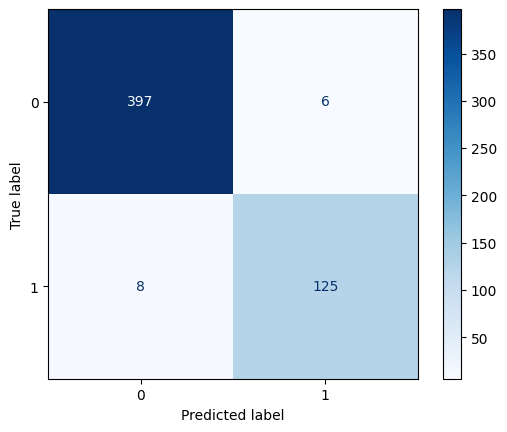

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# ===== 1. Prepare Data =====
jollibee_df = gdf_jollibee.copy()
jollibee_df["label"] = 1

random_df = gdf_combined.copy()
random_df["label"] = 0

# Set aside part of random_df as candidate locations (unlabeled for model training)
candidate_df = random_df.sample(frac=0.2, random_state=42)  # 20% as candidates
train_random_df = random_df.drop(candidate_df.index)

# Combine training data
df_train = pd.concat([jollibee_df, train_random_df], ignore_index=True).fillna(0)

features = [
    'nearest_mall', 'nearest_gas', 'nearest_hei',
    #'nearest_transpo', 'nearest_hotel',
    'malls_within_0.5km', 'gas_within_0.5km', 'heis_within_0.5km',
    'malls_within_0.1km', 'gas_within_0.1km', 'heis_within_0.1km'
]

X = df_train[features]
y = df_train["label"]

# ===== 2. Train/Test Split for Evaluation =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=75, stratify=y
)

# ===== 3. Train Gradient Boosting =====
model = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
#model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',random_state=42)
model.fit(X_train, y_train)

# ===== 4. Evaluate =====
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== Model Performance =====")
print(f"ROC AUC: {roc_auc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")

# ===== 5. Retrain on FULL training dataset =====
model.fit(X, y)

# ===== 6. Score Candidates =====
candidate_df = candidate_df.fillna(0).copy()
X_candidates = candidate_df[features]
candidate_df["Score"] = model.predict_proba(X_candidates)[:, 1]

# ===== 7. Rank Candidates =====
ranking_df = candidate_df.sort_values(by="Score", ascending=False).head(50)
print("\n===== Top Candidate Locations =====")
print(ranking_df[['Latitude','Longitude',"Score"]])


## 🌐 Convert Results to GeoDataFrame

We transform ranked candidate locations into a spatial format for mapping and visualization.

In [19]:
import geopandas as gpd

# Convert ranking_df to GeoDataFrame (assuming it has 'Latitude' and 'Longitude')
ranking_gdf = gpd.GeoDataFrame(
    ranking_df,
    geometry=gpd.points_from_xy(ranking_df['Longitude'], ranking_df['Latitude']),
    crs="EPSG:4326"
)

# Ensure both are in the same projected CRS for meter-based distance calculation
ranking_proj = ranking_gdf.to_crs(epsg=32651)    # UTM Zone 51N (covers Metro Manila)
jollibee_proj = jollibee_gdf.to_crs(epsg=32651)

# Buffer Jollibee locations by 500 meters
jollibee_buffer = jollibee_proj.buffer(200)

# Filter top scorers that are NOT within 500 m of any existing Jollibee
far_from_jollibees = ranking_proj[~ranking_proj.intersects(jollibee_buffer.union_all())]

# Convert back to WGS84 for mapping
ranking_df_filtered=ranking_proj[
    ~ranking_proj.intersects(jollibee_buffer.union_all())
].head(10)

ranking_df_filtered.to_csv('top10jollibee.csv', index=False)

print(ranking_df_filtered[['Latitude','Longitude',"Score"]])

       Latitude   Longitude     Score
411   14.443096  120.996549  0.297280
1192  14.559774  120.995124  0.061019
1387  14.705251  121.082457  0.049506
1355  14.694091  120.967945  0.039100
560   14.700585  120.962282  0.018342
439   14.588489  121.044012  0.018221
1412  14.721434  121.040229  0.010927
723   14.581757  121.029365  0.009957
353   14.669055  120.975561  0.006273
744   14.528095  121.005332  0.005866


## 🗺️ Interactive Map of Recommended Sites

We create an interactive map showing top-ranked locations for potential Jollibee expansion.

In [20]:
import folium

# Reproject for centroid calc
metro_proj = metro_manila.to_crs(epsg=3857)
center_lat = metro_proj.geometry.centroid.to_crs(epsg=4326).y.mean()
center_lon = metro_proj.geometry.centroid.to_crs(epsg=4326).x.mean()

# Prepare for Folium: keep only geometry + simple string fields
cols_to_keep = ['ADM3_EN', 'geometry']
metro_for_map = metro_manila[cols_to_keep].copy()

# Make sure CRS is WGS84
metro_for_map = metro_for_map.to_crs(epsg=4326)

# Create folium map
m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Add Metro Manila boundary
folium.GeoJson(
    metro_for_map,
    name="Metro Manila Boundary",
    style_function=lambda x: {
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0
    }
).add_to(m)

# Plot current Jollibees
for _, row in jollibee_gdf.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color="black",          # border color
        weight=1,
        fill=True,
        fill_color="red",       # fill color
        fill_opacity=0.85,
        popup=folium.Popup(
            f"{row['Name']}",
            max_width=250
        )
    ).add_to(m)

# Plot top candidates
for _, row in ranking_df_filtered.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        icon=folium.Icon(color='orange', icon='star', prefix='fa'),
        popup=folium.Popup(
            "Jollibee Store",
            max_width=200
        )
    ).add_to(m)

# Show map
m.save("top10_jollibee_candidates.html")
m


## ✅ Conclusion

This notebook demonstrates a data-driven approach to site selection using:
- Geospatial analysis
- Machine learning
- Location intelligence

The final output highlights optimal locations for new Jollibee stores in Metro Manila.